# Simple Linear Regression 

-- In Simple Linear Regression We Only have one input and we only get one output <br>
-- so if we provide the weight the model should tell us the hieght of it <br>
-- Here we will create a best fit line where the predicted points should be shortest <br>
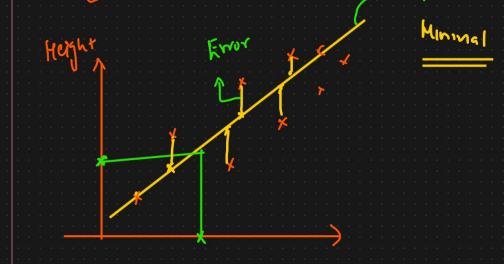<br>
__________________________________________________________________________________________

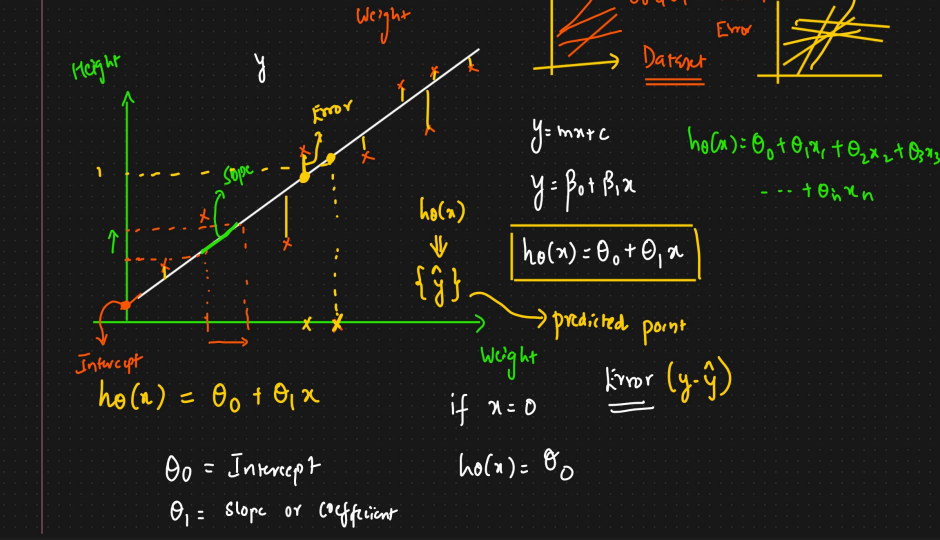

________________________________________________________________________________________
We have to select that kind of line where the sum of all the error of the inputs points should be minimun <br>

# Cost Function In Linear Regression <br>

Formula of cost funtion <br>
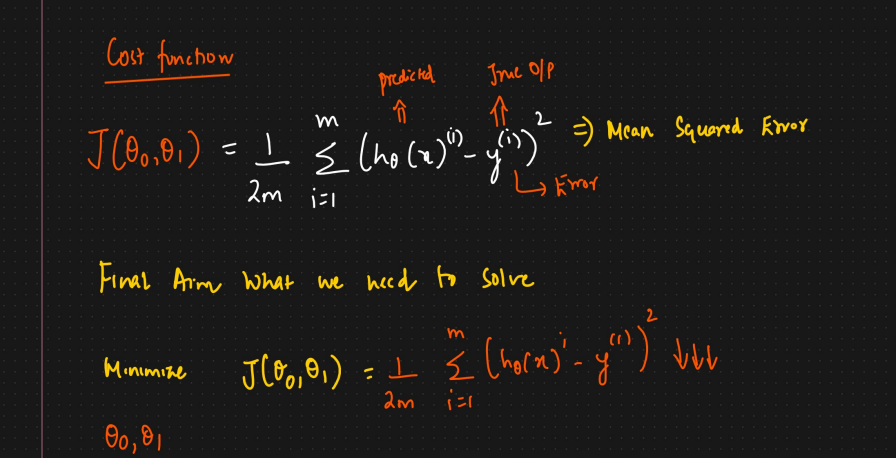 <br>
Here theta0 is the intercept whereas theta1 is the slope of a line  <br>

where-ever our cost function is miniman than we can say that we are very close to the best fit line 
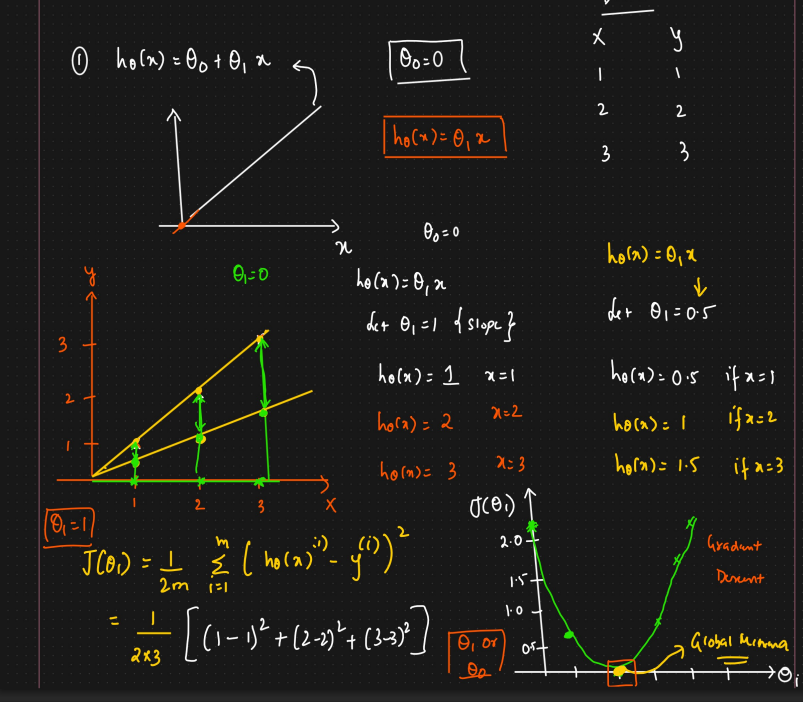 <br>
Here in the gradiant discent whereever we will get global minima that will be the best fit line 
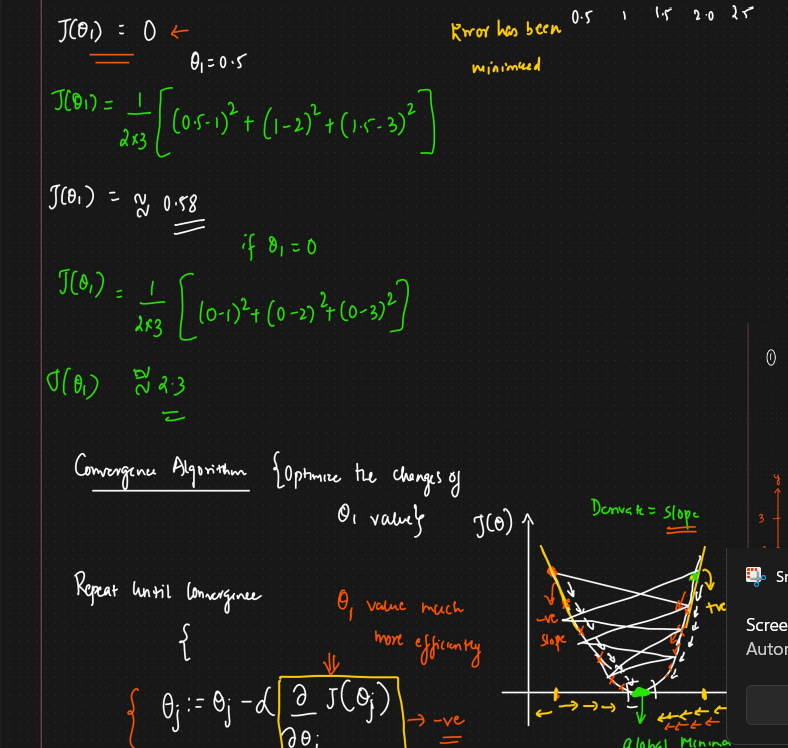 <br>
the above formula will help us to optimize how to change our theta value 
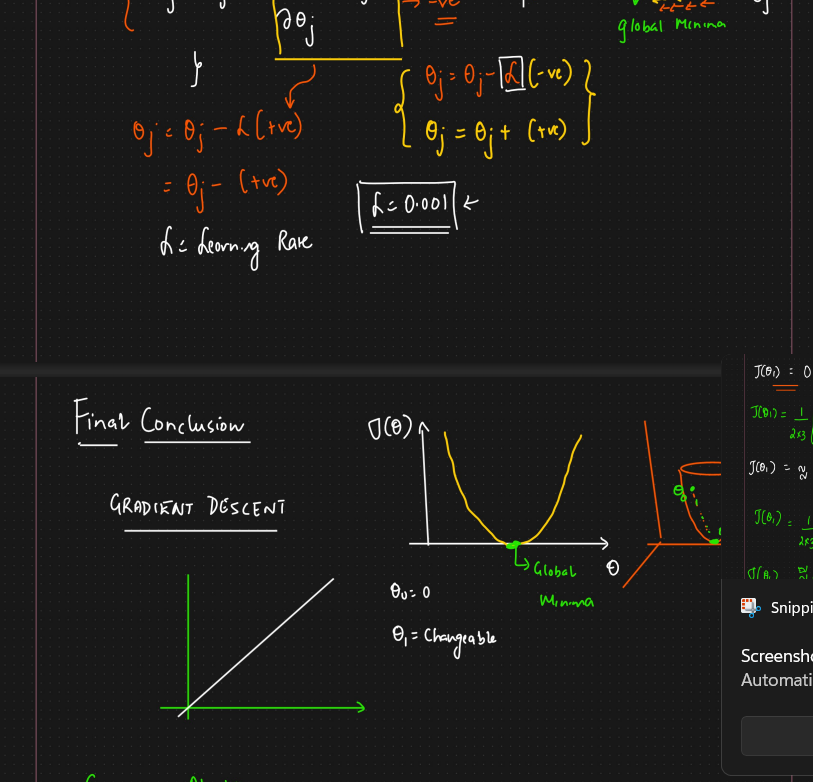 <br>
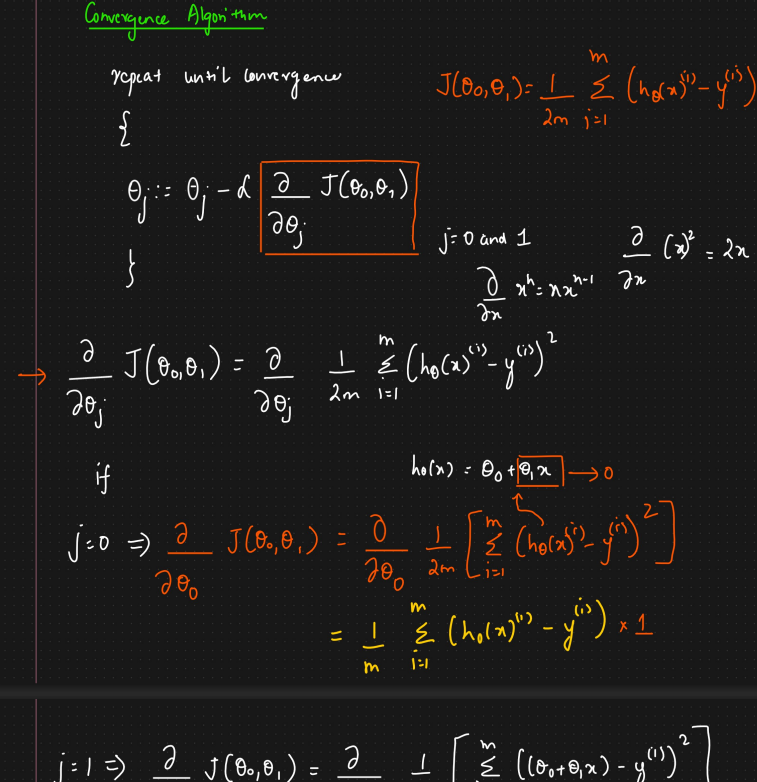 <br>
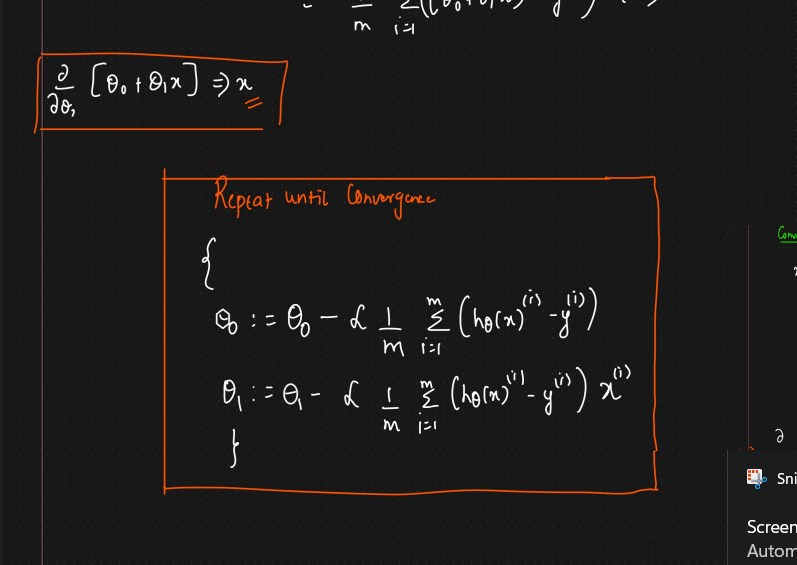 <br>


Multiple Linear Regression <br>
Here their will be more than theta1 ,theta2 etc<br>


Performance Metrice Used In Linear Regression <br>
1) R Squared<br>
2) Adjusted R Squared<br>

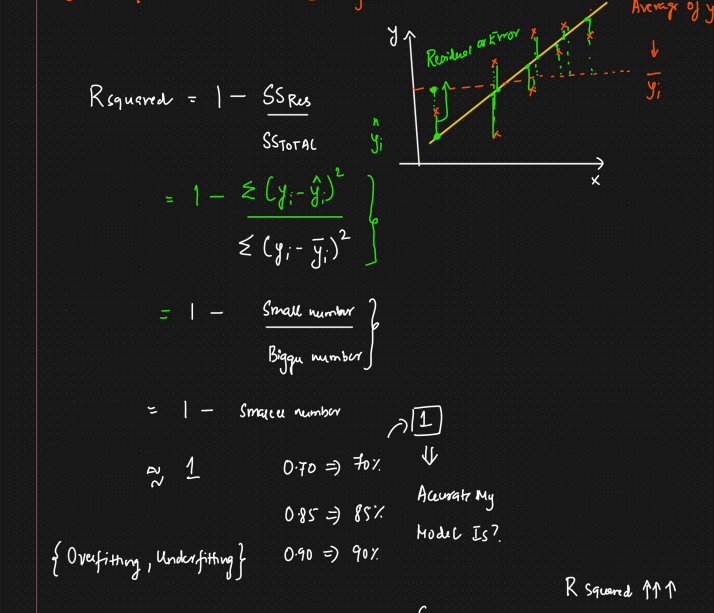<br>
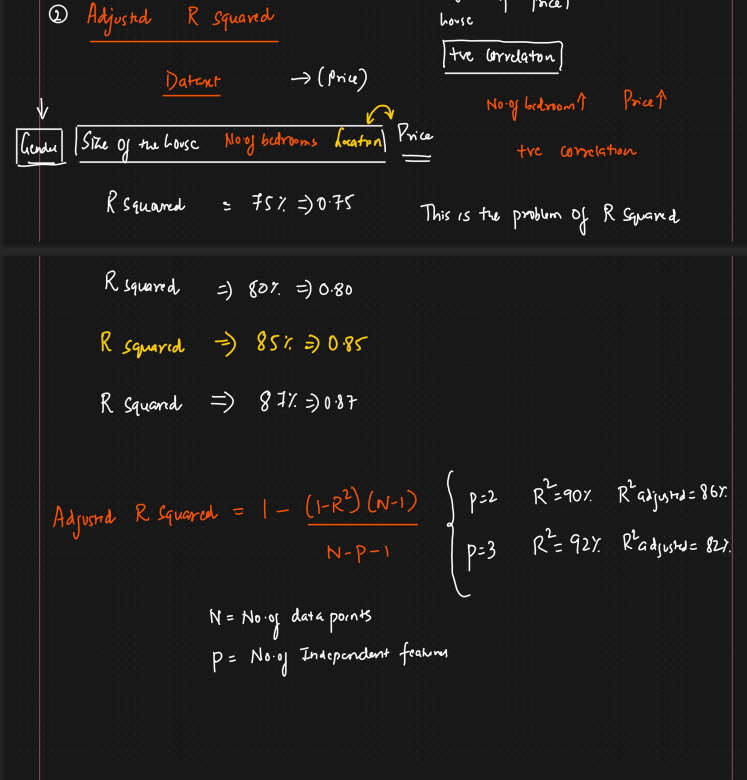<br>

## MSE , MAE , RMSE <br>
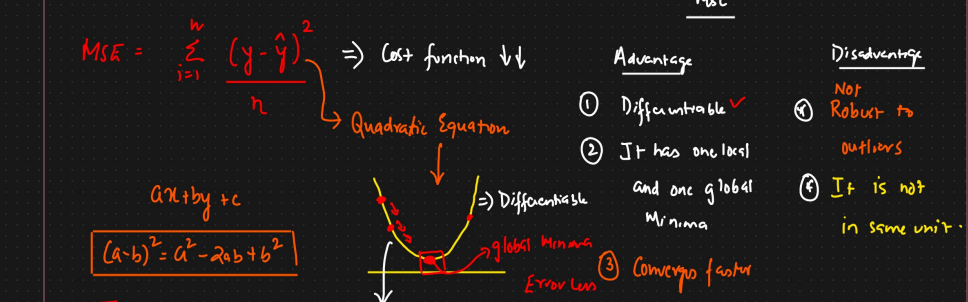<br>
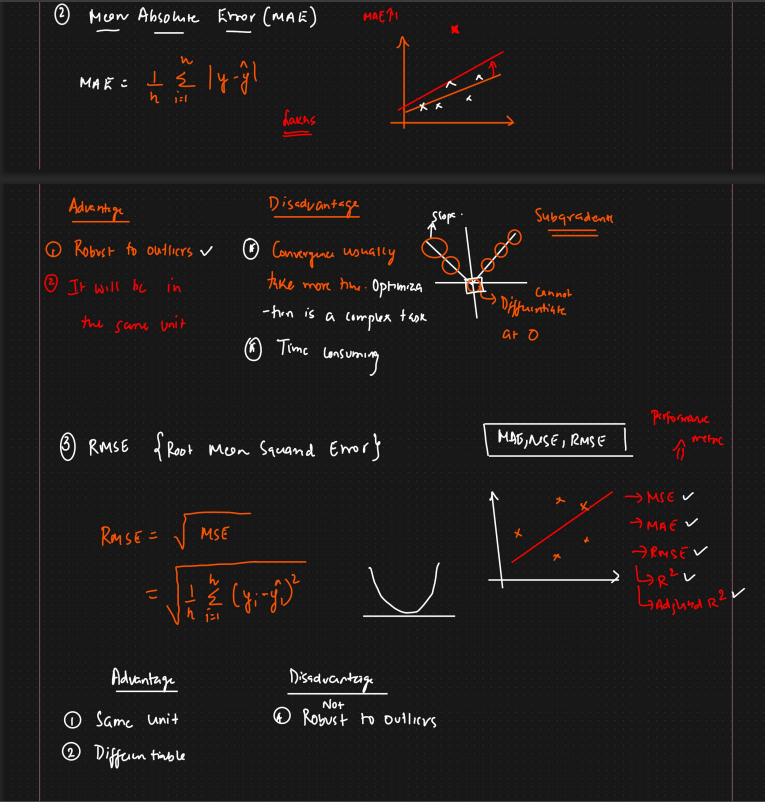<br>

## OverFitting And UnderFitting 

--Whenever we get any data set divide it into training and test data set like if we have 1000 datapoint than use 700 for training dataset and 300 for test dataset and dont show test dataset to the model while training 
--Further divide the training dataset into two part one for training the model and one for validation 

1) OverFitting :-
When my model gives very good accuracy for training data(low bias) and for test data we are getting very bad accuracy(high variance)
 
3) UnderFitting :-
When my model gives very low accuracy(high bias) for training data and for test data we are getting very bad accuracy(high Variance)

## Linear Regression Using OLS (oridinary Least Square) <br>

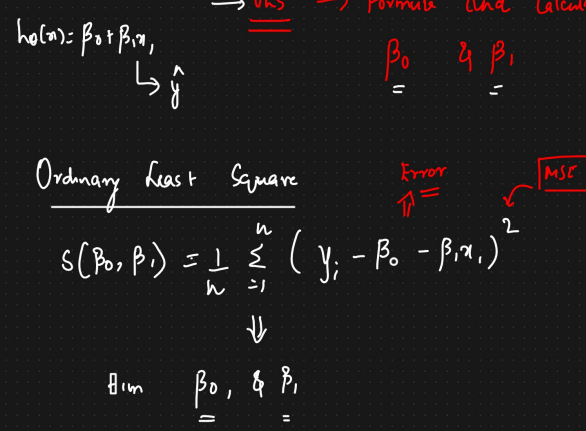<br>
After differentiating with beta0 and beta 1 we will get :- <br>
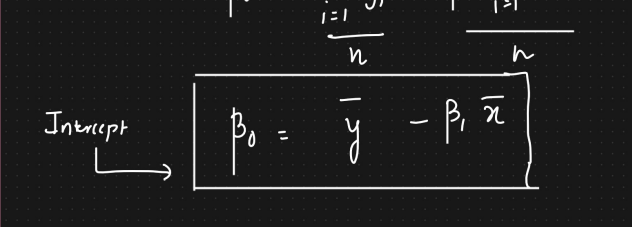<br>
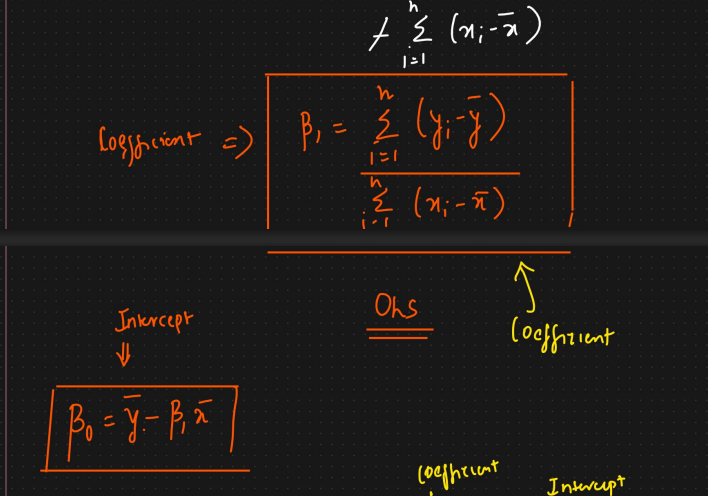<br>

# Linear Regression In Practical :- (imp)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv('height-weight.csv')

df.head()

plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("height")

df.corr()

sns.pairplot(df)

# Independent and dependent features 
# Whenever we are creating independent features it should always be dataframe or 2 dim array never put it in series
# Whereas while creating dependent features we can create it in the form of series or 1 dim array
X = df[['Weight']]
Y = df['Height']

# Train , Test , Split 
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size=0.25 , random_state=42)

##Standardization 
# Agar koi cheez kg mai calculate ho rahi hai and kahi cm mai toh ek particular units pe dono ko lana padega so 
# where it will convert all the values into mean = 0 and standard deviation = 1
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)
# here fit_transform will basically standardize the data
# and in x_test we will use only transform as with that function it will take mean and standard devaition of fit_transform only 

# Apply simple Linear Regression 
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train , Y_train)
# This is the slope of the line 
# This says 1 unit movement in the y value it does 17.29 movement in the x value
print("slope : " , regression.coef_)
# when the x is 0 where the line will meet in the y axis
print("intercept : " , regression.intercept_)

# plot training data plot best fit line
plt.scatter(X_train , Y_train)
plt.plot(X_train , regression.predict(X_train))

# Prediction for the test data
y_pred = regression.predict(X_test)

# performance Metrics 
from sklearn.metrics import mean_absolute_error , mean_squared_error 

# performance Metrics 
from sklearn.metrics import mean_absolute_error , mean_squared_error 

mse = mean_squared_error(Y_test,y_pred) 
mae = mean_absolute_error(Y_test,y_pred) 
rmse = np.sqrt(mse)
print (mse)
print (mae)
print (rmse)

from sklearn.metrics import r2_score
score = r2_score(Y_test , y_pred)
print(score)

# Ols Linear Regression 
import statsmodels.api as sm
model = sm.OLS(Y_train , X_Train).fit()
prediction = model.predict(X_test)

# prediction for new data 
regression.predict(scaler.transform([[72]]))

## Multiple Linear Regressiona Practical (IMP)

In [ ]:
# Here almost everything will be same the only difference is here in the dependent varible we use more than one variable and here we also have
# few different garphs to visvualize 
sns.pairplot(df)

# Independent and dependent features 
# Whenever we are creating independent features it should always be dataframe or 2 dim array never put it in series
# Whereas while creating dependent features we can create it in the form of series or 1 dim array
X = df[['Weight' , 'age' , 'gender']] # Here we provide more than one dependent variable 
Y = df['Height']

sns.regplot(x = df['interest_rate'],y = df['index_price'] ) # this is used to visulaze that whether it follows linear  regresssion or not 

# Assumptions that we made to find weather our data will follow linear regression or not 

# 1.if the below graph preform some linear kind of relation that we can say that the model is performing well 
plt.scatter(Y_test , Y_pred)

# 2. if here we get some normal distribution kind of curve than we can say that the model has performed well 
residuals = Y_test - Y_pred
sns.displot(residuals , kind='kde')

# scatter plot with respect to prediction and residuals 
# 3. Here if the data is distributed everywhere than we can say that the model is good
plt.scatter(Y_pred , residuals)

## Polynomial Regression <br>

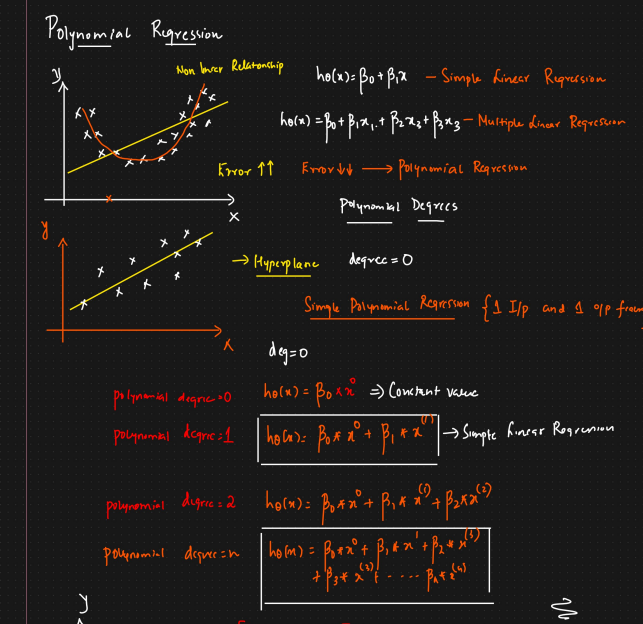

In [ ]:
## Partical usecase of polynomial regression 

# Here everything is simial expect hume X_train and Y_Train ki jaga ye use :-

# -- lets apply polynomial transformation 
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2 , include_bias = True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
# basically now we have to use this as our X_train and X_test 

In [ ]:
## How to create pipeline for our lienar regression 

# pipeline 
from sklearn.pipeline import Pipeline
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()

## Ridge Regression And Lasso And ElasticNet <br>

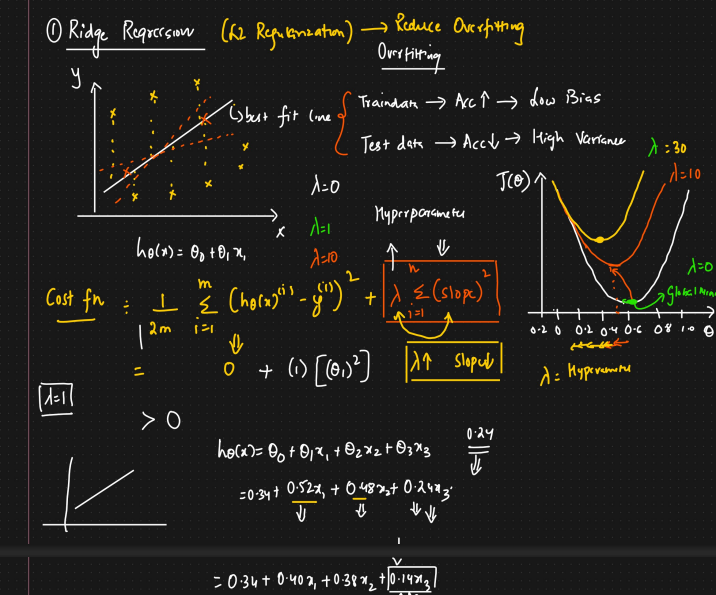<br>
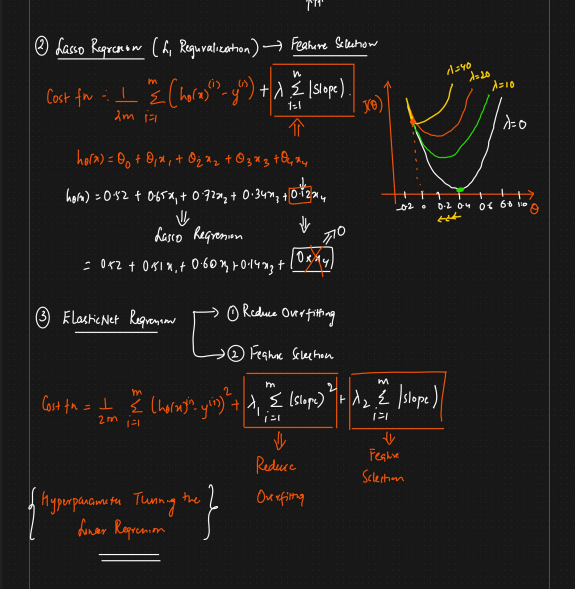<br>

## Different Type Of Cross Validation <br>
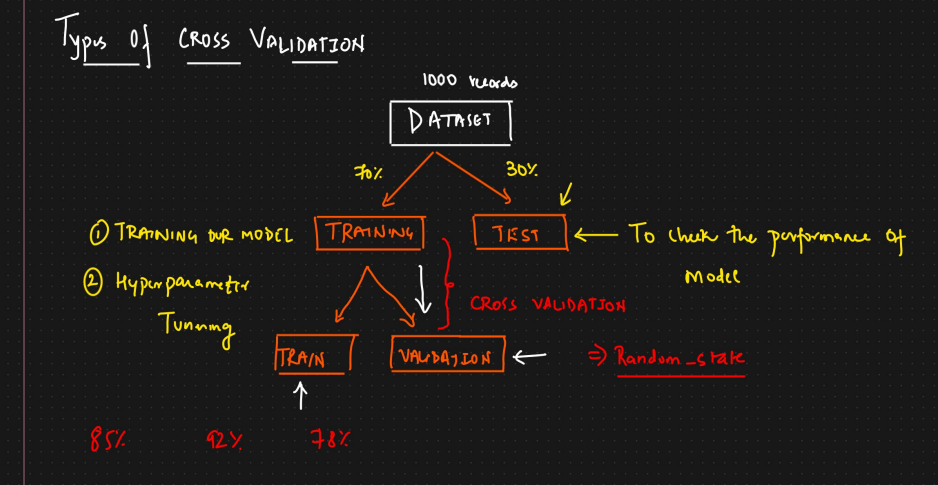<br>
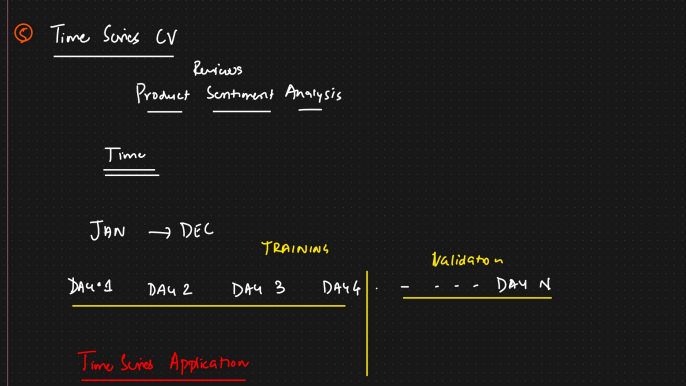<br>
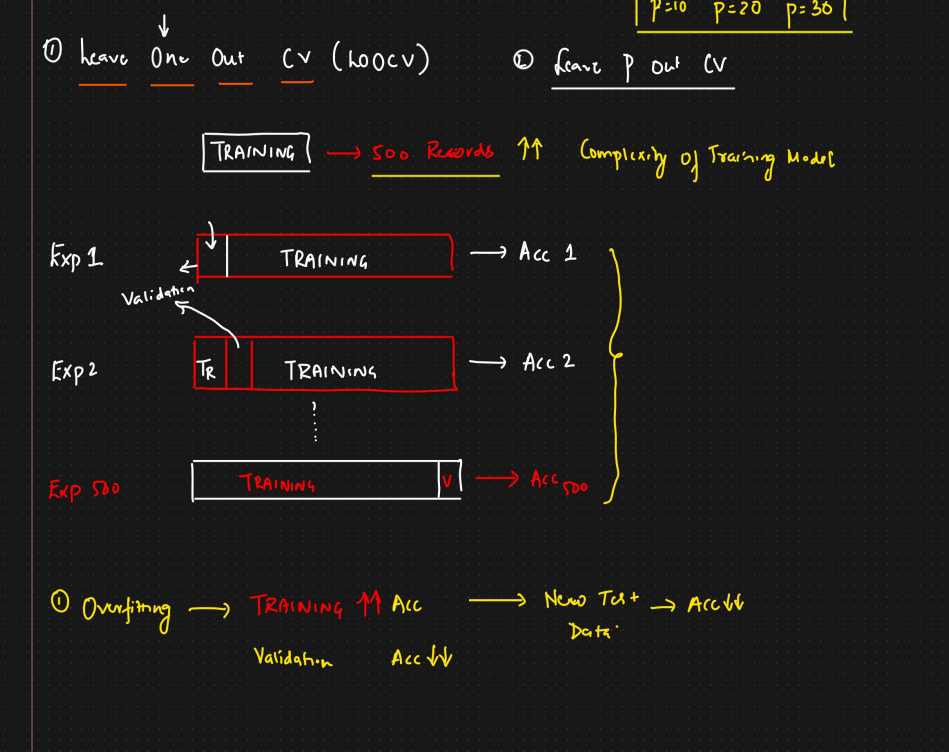<br>
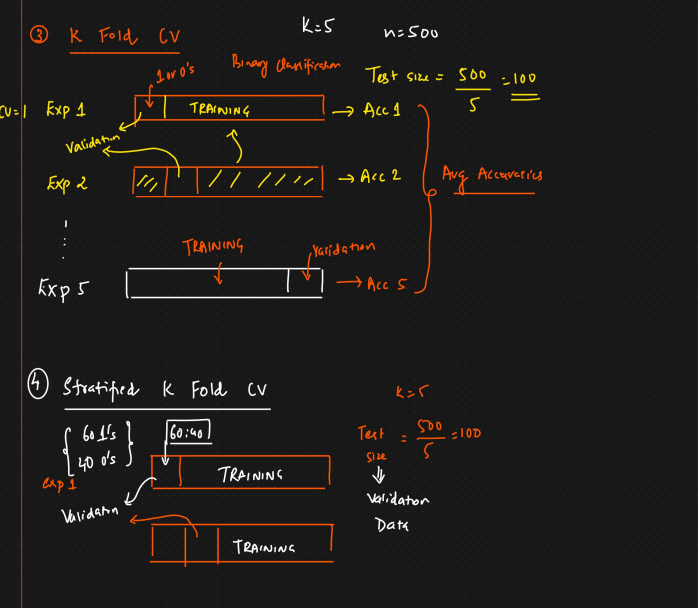<br>
